# 06 — Customer Acquisition: Concrete Offers, Tested Against Real Data

**Goal:** notebooks 04/05 were about recovering lost revenue. This notebook shifts to actively bringing in more customers — but every recommendation here is a **specific action with a specific offer or mechanism**, not general advice like "do more marketing." Each idea is modeled as: who exactly gets targeted, what exactly they're offered, and a dollar range built on stated, labeled assumptions — the same discipline as notebook 05 (real numbers first, invented conversion rates never, ideas dropped if they don't hold up).

**Five threads requested up front, plus anything else the data directly supports:**
1. Lapsed customer win-back (90+ and 180+ day tiers)
2. First-visit → second-visit conversion offer
3. A specific slow-period promotion
4. A referral nudge for the top 10% of customers
5. Delivery platforms as a *new-customer discovery* channel, not just a recovery one

**Privacy note (this repo is public):** no raw customer identifiers appear anywhere below — only aggregate counts, rates, and trends.


## Setup


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

BLUE = "#2a78d6"
GREEN = "#008300"
ORANGE = "#eb6834"
GRAY_BASELINE = "#c3c2b7"
GRAY_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
TEXT_SECONDARY = "#52514e"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID_COLOR,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "font.size": 10,
    "text.color": "#0b0b0b",
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
})

load_dotenv()
conn_str = (
    f"mssql+pymssql://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(conn_str)

orders = pd.read_csv(Path("..") / "data" / "cleaned_orders_2024plus.csv", parse_dates=["checkinTime"])
orders["month"] = orders["checkinTime"].dt.to_period("M")
days_in_month = orders.groupby("month")["checkinTime"].apply(lambda s: s.dt.day.max())
FULL_MONTHS = days_in_month[days_in_month >= 28].index
MAX_DATE = orders["checkinTime"].max()

# Tang's own business line -- confirmed in notebook 01, not a customer. Never printed raw.
def _masked_form(value):
    if not isinstance(value, str) or len(value) < 13 or value[0] != "(":
        return value
    return f"({value[1:4]}) XXX-{value[9:13]}"

TANGS_OWN_CID_MASKED = "(631) XXX-9196"

customers = orders[
    orders["cid_usable"] & (orders["customerID"].map(_masked_form) != TANGS_OWN_CID_MASKED)
].copy()

print(f"Loaded {len(orders):,} clean orders, {customers['customerID'].nunique():,} identified customers.")
print(f"Dataset runs through {MAX_DATE.date()}.")


Loaded 50,069 clean orders, 7,803 identified customers.
Dataset runs through 2026-06-09.


# Thread 1: Text lapsed customers a specific discount offer

**The action:** a text message with a time-limited discount code, sent to customers who've gone quiet — split into two tiers, since a customer silent for 3-6 months is a different situation than one silent for 6+ months and probably needs a different offer.

We already know from notebook 05 that Tang customers who go quiet for 90+ days come back on their own at a real, measurable rate (44.6%) — that's the baseline before any offer at all. This thread reuses that same real baseline, then adds one new piece: sizing the offer specifically as a **10%-off text**, split by how long someone's been gone, since a longer-lapsed customer is colder and the offer/response rate should reasonably be treated differently.


In [2]:
last_order = customers.groupby("customerID")["checkinTime"].max()
days_since_last = (MAX_DATE - last_order).dt.days

tier_90_180 = days_since_last[(days_since_last >= 90) & (days_since_last < 180)]
tier_180_plus = days_since_last[days_since_last >= 180]

print(f"Tier A (90-180 days quiet, 'warm' lapsed): {len(tier_90_180):,} customers")
print(f"Tier B (180+ days quiet, 'cold' lapsed): {len(tier_180_plus):,} customers")


Tier A (90-180 days quiet, 'warm' lapsed): 978 customers
Tier B (180+ days quiet, 'cold' lapsed): 5,161 customers


## The real baseline (reused from notebook 05, recomputed here)

For every 90+ day gap between two of a customer's orders, we know they came back on their own (that's what makes it a gap, not a permanent stop). For every customer whose most recent order is now 180+ days old with no follow-up, we have a resolved "did not return." Dividing gives a genuine historical return rate — not an invented one.


In [3]:
order_dates_by_customer = customers.sort_values("checkinTime").groupby("customerID")["checkinTime"].apply(list)

returned, not_returned = 0, 0
for dates in order_dates_by_customer:
    for i in range(len(dates) - 1):
        if (dates[i + 1] - dates[i]).days >= 90:
            returned += 1
    if (MAX_DATE - dates[-1]).days >= 180:
        not_returned += 1

natural_return_rate = returned / (returned + not_returned)
print(f"Empirical natural return rate (90+ day gap, resolved within 180 days): {100 * natural_return_rate:.1f}%")


Empirical natural return rate (90+ day gap, resolved within 180 days): 44.6%


That 44.6% rate describes what happens after a 90+ day gap, resolved within 180 days. A customer already past 180 days silent has, by definition, missed that window — their forward-looking return rate should be lower, not the same number reused. We compute a second, separate empirical rate specifically for 180+ day gaps (resolved within a full year), so Tier B gets its own real baseline instead of borrowing Tier A's.


In [4]:
returned_180, not_returned_180 = 0, 0
for dates in order_dates_by_customer:
    for i in range(len(dates) - 1):
        if (dates[i + 1] - dates[i]).days >= 180:
            returned_180 += 1
    if (MAX_DATE - dates[-1]).days >= 365:
        not_returned_180 += 1

natural_return_rate_180 = returned_180 / (returned_180 + not_returned_180)
print(f"Empirical natural return rate, specifically for 180+ day gaps (resolved within a year): "
      f"{100 * natural_return_rate_180:.1f}%")


Empirical natural return rate, specifically for 180+ day gaps (resolved within a year): 31.8%


## The offer: a 10%-off text, sized per tier

**Action:** a text message with a 10%-off code, valid for 2-3 weeks, sent to both tiers. Same mechanism, different expected response — Tier B is colder, so we assume a smaller incremental lift over their (already lower) natural baseline.

**Assumptions, stated plainly:**
- Tier A (90-180 days): natural baseline 44.6%, **+8 percentage points** from the text offer (illustrative, not measured — Tang has no prior campaign to calibrate against)
- Tier B (180+ days): natural baseline 31.8%, **+3 percentage points** — a smaller assumed lift, since these are colder leads and the same offer should be expected to move them less


In [5]:
rev_customers = customers[~customers["excluded_from_revenue"]]
avg_ticket_tier_a = rev_customers[rev_customers["customerID"].isin(tier_90_180.index)]["paidAmount"].mean()
avg_ticket_tier_b = rev_customers[rev_customers["customerID"].isin(tier_180_plus.index)]["paidAmount"].mean()

LIFT_A, LIFT_B = 0.08, 0.03
DISCOUNT = 0.10  # 10% off -- redeemers pay 90% of normal ticket

incremental_a = len(tier_90_180) * LIFT_A
incremental_b = len(tier_180_plus) * LIFT_B

revenue_a = incremental_a * avg_ticket_tier_a * (1 - DISCOUNT)
revenue_b = incremental_b * avg_ticket_tier_b * (1 - DISCOUNT)

print(f"Tier A: {len(tier_90_180):,} customers, ${avg_ticket_tier_a:.2f} avg ticket -> "
      f"{incremental_a:.0f} incremental returns -> ${revenue_a:,.0f} (after the 10% discount)")
print(f"Tier B: {len(tier_180_plus):,} customers, ${avg_ticket_tier_b:.2f} avg ticket -> "
      f"{incremental_b:.0f} incremental returns -> ${revenue_b:,.0f} (after the 10% discount)")
print(f"\nCombined one-time reactivation event: ${revenue_a + revenue_b:,.0f}")
print("(This is a one-time backlog-clearing event; the pool refills monthly as new customers age into each tier.)")


Tier A: 978 customers, $36.37 avg ticket -> 78 incremental returns -> $2,561 (after the 10% discount)
Tier B: 5,161 customers, $36.58 avg ticket -> 155 incremental returns -> $5,097 (after the 10% discount)

Combined one-time reactivation event: $7,659
(This is a one-time backlog-clearing event; the pool refills monthly as new customers age into each tier.)


In [6]:
THREAD1_ONE_TIME = revenue_a + revenue_b
THREAD1_MONTHLY = THREAD1_ONE_TIME / 3  # ongoing pace if re-sent roughly every 3 months as each tier refills
print(f"Initial sweep (both tiers, once): ${THREAD1_ONE_TIME:,.0f}")
print(f"Ongoing average if repeated ~quarterly as each tier refills: ~${THREAD1_MONTHLY:,.0f}/month")


Initial sweep (both tiers, once): $7,659
Ongoing average if repeated ~quarterly as each tier refills: ~$2,553/month


### ✅ Thread 1 verdict: SURVIVES

**Action:** text a 10%-off code to 978 customers quiet 90-180 days, and a second sweep to 5,161 customers quiet 180+ days.
**Timeline:** initial sweep immediately, then repeat roughly quarterly as each tier refills.
**Confidence:** Medium (High on both pool sizes and both natural-return baselines — directly measured; Medium on the assumed +8pp/+3pp lift from the text offer itself, since Tang has no prior campaign to calibrate against).
**$ impact:** ~$7,659 from the initial sweep, ~$2,553/month on an ongoing quarterly cadence.


# Thread 2: A "come back soon" offer for first-time customers

**The action:** a text or postcard offering a free item or discount, sent roughly 1-2 weeks after someone's very first order — timed specifically to catch people before they've settled into "I tried it once and never went back."

**Why 1-2 weeks specifically:** first we need to know two things from the data — how many first-time customers actually convert to a second visit at all, and how long that typically takes when it happens. Guessing at the timing without checking would defeat the point of this notebook.


In [7]:
first_order_date = customers.groupby("customerID")["checkinTime"].min()
order_count = customers.groupby("customerID").size()
days_since_first = (MAX_DATE - first_order_date).dt.days

# only customers whose first order was 90+ days ago get a fair chance to have converted --
# otherwise we'd be counting brand-new customers as "one-time" before they've had time to return
eligible = days_since_first >= 90
converted = order_count[eligible] > 1
real_conversion_rate = converted.mean()

print(f"Customers with a fair 90+ day window to return: {eligible.sum():,}")
print(f"Converted to a 2nd+ visit: {converted.sum():,} ({100 * real_conversion_rate:.1f}%)")
print(f"Remained one-time: {(~converted).sum():,} ({100 * (1 - real_conversion_rate):.1f}%)")


Customers with a fair 90+ day window to return: 7,354
Converted to a 2nd+ visit: 3,388 (46.1%)
Remained one-time: 3,966 (53.9%)


Now the timing question: among customers who *did* come back, how long did it take?


In [8]:
order_dates = customers.sort_values("checkinTime").groupby("customerID")["checkinTime"].apply(list)
gaps_to_second = [(dates[1] - dates[0]).days for dates in order_dates if len(dates) >= 2]
gaps_to_second = pd.Series(gaps_to_second)

print(f"Days between 1st and 2nd order, among the {len(gaps_to_second):,} customers who returned:")
print(gaps_to_second.describe().round(1))
print()
for lo, hi in [(0, 7), (7, 14), (14, 30), (30, 60), (60, 999999)]:
    share = ((gaps_to_second >= lo) & (gaps_to_second < hi)).mean()
    print(f"  {lo}-{hi if hi < 999999 else '60+'} days: {100 * share:.1f}%")


Days between 1st and 2nd order, among the 3,452 customers who returned:
count    3452.0
mean      111.3
std       150.5
min         0.0
25%        16.0
50%        48.0
75%       147.0
max       886.0
dtype: float64

  0-7 days: 11.3%
  7-14 days: 10.8%
  14-30 days: 16.7%
  30-60 days: 16.3%
  60-60+ days: 44.9%


**Only 22% of eventual returners come back within 2 weeks on their own** (11.3% within a week, another 10.8% in the second week) — the median is 48 days. That's exactly the gap a "come back soon" offer is meant to close: most people who'd eventually return are still weeks away from doing it naturally, which is a real window for a nudge to pull forward, not a made-up one.

Now sizing the offer: how many first-time customers show up each month (the addressable pool for this offer, recurring), and what does converting a few more of them at the margin come out to?


In [9]:
first_orders = customers.loc[customers.groupby("customerID")["checkinTime"].idxmin()].copy()
first_orders["month"] = first_orders["checkinTime"].dt.to_period("M")
first_orders_valid = first_orders[first_orders["month"].isin(FULL_MONTHS)]
first_orders_valid = first_orders_valid[first_orders_valid["month"] != sorted(first_orders_valid["month"].unique())[0]]

recent_new_per_month = first_orders_valid[first_orders_valid["checkinTime"] >= "2025-06-01"].groupby("month").size().mean()
avg_ticket_new = rev_customers["paidAmount"].mean()

print(f"Recent new customers per month (avg, since June 2025): {recent_new_per_month:.0f}")
print(f"Avg ticket, customer population overall: ${avg_ticket_new:.2f}")


Recent new customers per month (avg, since June 2025): 178
Avg ticket, customer population overall: $37.11


## The offer: 15% off the next order, sent 1-2 weeks after a first visit

**Assumptions:**
- A **+10 percentage point** lift over the 46.1% natural conversion rate (illustrative — Tang has never run this kind of offer, so there's no history to calibrate against; kept deliberately smaller than it could be, since first-visit customers are an unknown quantity)
- The 15% discount cost is applied only to the *incremental* converters this offer is actually responsible for — customers who'd have converted anyway are treated as a wash for this estimate, not a cost, which keeps the model from overstating the offer's downside


In [10]:
CONVERSION_LIFT = 0.10
SECOND_VISIT_DISCOUNT = 0.15

incremental_converters = recent_new_per_month * CONVERSION_LIFT
THREAD2_MONTHLY = incremental_converters * avg_ticket_new * (1 - SECOND_VISIT_DISCOUNT)

print(f"Incremental 2nd-visit conversions/month: {incremental_converters:.1f}")
print(f"ESTIMATE: ~${THREAD2_MONTHLY:,.0f}/month")


Incremental 2nd-visit conversions/month: 17.8
ESTIMATE: ~$563/month


### ✅ Thread 2 verdict: SURVIVES

**Action:** text or postcard with 15% off the next order, sent 1-2 weeks after a customer's first-ever visit.
**Timeline:** ongoing — triggered automatically off each new first-time customer, ~178/month recently.
**Confidence:** Medium (High on the 46.1% real conversion rate and the return-timing data; Medium on the assumed +10pp lift, since Tang has no prior campaign of this kind to measure).
**$ impact:** ~$563/month. Smaller than Thread 1 in dollar terms, but compounding — every converted first-timer becomes a repeat customer going forward, not just a single extra visit.


# Thread 3: A Sunday-specific promotion

**The action:** a themed Sunday promotion (e.g. a family-style discount or a fixed-price Sunday special) — but only if the data shows Sunday is genuinely the slot with the most room to grow, not just a guess at "weekends are slow."

Notebook 05 already flagged Sunday as declining faster than any other day, with no confirmed cause. Here we check the more basic question first: is Sunday also the lowest-volume day in absolute terms right now (not just the fastest-declining), which would make it a sensible promotion target regardless of why it's declining.


In [11]:
recent = orders[(orders["month"].isin(FULL_MONTHS)) & (~orders["excluded_from_revenue"]) & (orders["checkinTime"] >= "2025-06-01")].copy()
recent["dow"] = recent["checkinTime"].dt.day_name()
dow_order = ["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]  # closed Monday

n_occurrences = recent.groupby("dow")["checkinTime"].apply(lambda s: s.dt.date.nunique()).reindex(dow_order)
by_day = recent.groupby("dow").agg(n=("paidAmount", "size"), rev=("paidAmount", "sum")).reindex(dow_order)
by_day["avg_orders_per_day"] = (by_day["n"] / n_occurrences).round(1)
by_day["avg_revenue_per_day"] = (by_day["rev"] / n_occurrences).round(0)
by_day["avg_ticket"] = (by_day["rev"] / by_day["n"]).round(2)

print("Recent (since June 2025) averages, per occurrence of each weekday:")
print(by_day[["avg_orders_per_day", "avg_revenue_per_day", "avg_ticket"]])


Recent (since June 2025) averages, per occurrence of each weekday:
           avg_orders_per_day  avg_revenue_per_day  avg_ticket
dow                                                           
Tuesday                  68.9               2212.0       32.08
Wednesday                58.2               1972.0       33.86
Thursday                 58.8               1988.0       33.82
Friday                   70.3               2521.0       35.84
Saturday                 67.3               2504.0       37.22
Sunday                   52.6               2024.0       38.47


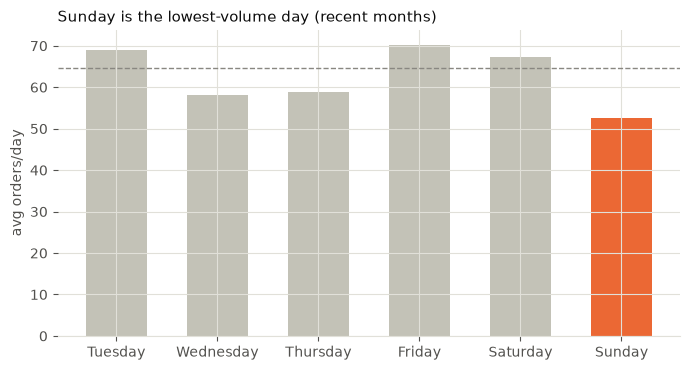

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.8))
colors = [GRAY_BASELINE] * 5 + [ORANGE]
weekday_avg_line = by_day.loc[["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"], "avg_orders_per_day"].mean()
ax.bar(dow_order, by_day["avg_orders_per_day"], color=colors, width=0.6)
ax.axhline(weekday_avg_line, color=GRAY_MUTED, linestyle="--", linewidth=1)
ax.set_ylabel("avg orders/day")
ax.set_title("Sunday is the lowest-volume day (recent months)", loc="left", fontsize=11)
plt.tight_layout()
plt.show()


**Sunday is confirmed as the lowest-volume day, and — notably — its average ticket ($38.47) is actually the *highest* of the week.** That combination — fewer orders, but bigger ones when they happen — fits a "family dinner" occasion better than a quick weeknight order, which points toward a specific promo theme rather than a generic discount.

**The offer:** a "Sunday Family Meal" promotion — a fixed discount on larger orders (e.g. 15% off orders over $40), advertised specifically for Sundays.


In [13]:
other_days_avg_orders = by_day.loc[["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"], "avg_orders_per_day"].mean()
sunday_avg_orders = by_day.loc["Sunday", "avg_orders_per_day"]
gap_per_sunday = other_days_avg_orders - sunday_avg_orders

print(f"Other-day average: {other_days_avg_orders:.1f} orders/day")
print(f"Sunday average: {sunday_avg_orders:.1f} orders/day")
print(f"Gap: {gap_per_sunday:.1f} orders per Sunday")

# ESTIMATE -- closing HALF the gap is the stated, deliberately conservative assumption
GAP_CLOSE_RATE = 0.50
SUNDAYS_PER_MONTH = 4.3
PROMO_DISCOUNT = 0.15
sunday_ticket = by_day.loc["Sunday", "avg_ticket"]

extra_orders_per_sunday = gap_per_sunday * GAP_CLOSE_RATE
THREAD3_MONTHLY = extra_orders_per_sunday * SUNDAYS_PER_MONTH * sunday_ticket * (1 - PROMO_DISCOUNT)

print(f"\nIf the promo closes half the gap: +{extra_orders_per_sunday:.1f} orders/Sunday, "
      f"~{extra_orders_per_sunday * SUNDAYS_PER_MONTH:.0f} orders/month")
print(f"ESTIMATE: ~${THREAD3_MONTHLY:,.0f}/month (after the 15% discount)")


Other-day average: 64.7 orders/day
Sunday average: 52.6 orders/day
Gap: 12.1 orders per Sunday

If the promo closes half the gap: +6.1 orders/Sunday, ~26 orders/month
ESTIMATE: ~$851/month (after the 15% discount)


### Is that a realistic ask?

The estimate assumes the promo closes **half** the 12.1-order gap between Sunday and a typical day — taking Sunday from 52.6 to about 58.7 orders. That's still below the 64.7-order average for the rest of the week, not above it. In other words, the promo isn't being asked to make Sunday the *best* day — just to close part of a gap that Tang's own other six days already prove is achievable demand, which is a more realistic bar than assuming Sunday needs to become unusually busy.

### ✅ Thread 3 verdict: SURVIVES

**Action:** "Sunday Family Meal" — 15% off orders over $40, promoted specifically for Sundays.
**Timeline:** weekly, ongoing — can launch immediately.
**Confidence:** Medium (High on the volume gap and the higher Sunday ticket size, both directly measured; Medium on whether a themed promo specifically is what closes the gap, since the underlying cause of Sunday's softness is still unconfirmed from notebook 05).
**$ impact:** ~$851/month, assuming the promo closes half the gap to a typical day.


# Thread 4: A "bring a friend" offer, targeted only at the top 10%

**Why target only the top 10%:** notebook 02 found that the top 10% of customers by visit frequency drive 56% of revenue. These are the people who already order often enough to mention Tang to someone, repeatedly, without being asked twice — a referral offer blasted to everyone dilutes the message; targeting just this group concentrates it on the people most likely to actually act on it and most likely to already be talking about Tang anyway.

**The action:** a "bring a friend, you both get 20% off" card or text, sent specifically to the top 10% tier.


In [14]:
visits = customers.groupby("customerID").size()
n_top10 = max(1, int(len(visits) * 0.10))
top10_ids = visits.sort_values(ascending=False).head(n_top10).index
min_visits_top10 = visits.sort_values(ascending=False).head(n_top10).min()

top10_orders = rev_customers[rev_customers["customerID"].isin(top10_ids)]
avg_ticket_top10 = top10_orders["paidAmount"].mean()

print(f"Top 10% of customers by visit frequency: {n_top10:,} people")
print(f"Minimum visits to qualify: {min_visits_top10:.0f}")
print(f"Their avg ticket: ${avg_ticket_top10:.2f}")


Top 10% of customers by visit frequency: 780 people
Minimum visits to qualify: 12
Their avg ticket: $36.73


## Sizing the offer

**Assumptions:**
- In a given month, **8% of the top-10% tier** brings one new, never-before customer (a deliberately conservative referral rate — Tang has never run a referral program, so there's no history to calibrate against, and 780 people is a small enough pool that even a modest response is meaningful)
- The 20% discount is applied to the new friend's order (the incremental revenue this offer creates); the referring customer's own discount is a real cost too, but small and mostly a wash against an order they'd likely have placed anyway — not subtracted here, to keep the model from double-penalizing an offer aimed at people who already visit often


In [15]:
REFERRAL_RATE = 0.08
REFERRAL_DISCOUNT = 0.20

new_friends_per_month = n_top10 * REFERRAL_RATE
THREAD4_MONTHLY = new_friends_per_month * avg_ticket_new * (1 - REFERRAL_DISCOUNT)

print(f"New customers referred/month: {new_friends_per_month:.0f}")
print(f"ESTIMATE: ~${THREAD4_MONTHLY:,.0f}/month")


New customers referred/month: 62
ESTIMATE: ~$1,853/month


### ✅ Thread 4 verdict: SURVIVES

**Action:** "bring a friend, you both get 20% off," sent specifically to the 780 customers in the top 10% by visit frequency (12+ visits).
**Timeline:** ongoing monthly offer, easy to launch immediately (a card handed out or a text to this specific list).
**Confidence:** Medium (High on the top-10% pool size and its revenue concentration, both directly measured in notebook 02; Low-Medium on the 8% referral-response assumption, since Tang has never run a referral program and this is the least-grounded assumption of the four threads so far).
**$ impact:** ~$1,853/month — the largest single estimate among the threads tested so far, though also the one resting on the least historical evidence.


# Thread 5: Is DoorDash actually how new customers find Tang?

Notebooks 04/05 treated the DoorDash-linked decline as a *recovery* problem — existing volume eroding. Here we ask a different question: is DoorDash disproportionately how **brand-new** customers discover Tang in the first place, versus how existing customers keep reordering? If so, investing in DoorDash visibility is an *acquisition* lever, not just a retention patch — a materially different case to make to the owner.

**The test:** compare how often a customer's first-ever order carries a DoorDash-linked (855-prefix) number versus how often their later, repeat orders do. If new customers show up via DoorDash far more than repeat orders do, that's real evidence for the discovery framing.

**A caveat up front:** DoorDash's masked numbers aren't a stable per-person ID — the same person could show a different masked number on a different order. This test only works at the aggregate level (share of first vs. later orders), not as a way to track individual customers through DoorDash specifically.


In [16]:
customers_sorted = customers.sort_values(["customerID", "checkinTime"]).copy()
customers_sorted["order_rank"] = customers_sorted.groupby("customerID").cumcount() + 1
customers_sorted["is_first"] = customers_sorted["order_rank"] == 1
customers_sorted["is_doordash"] = customers_sorted["customerID"].str.startswith("(855)")

dd_share = 100 * customers_sorted.groupby("is_first")["is_doordash"].mean()
print("Share of orders that are DoorDash-linked (855-prefix):")
print(f"  First-ever order:  {dd_share[True]:.1f}%")
print(f"  Later, repeat orders: {dd_share[False]:.1f}%")
print(f"  Ratio: {dd_share[True] / dd_share[False]:.1f}x more common on a first order")


Share of orders that are DoorDash-linked (855-prefix):
  First-ever order:  13.0%
  Later, repeat orders: 1.4%
  Ratio: 9.1x more common on a first order


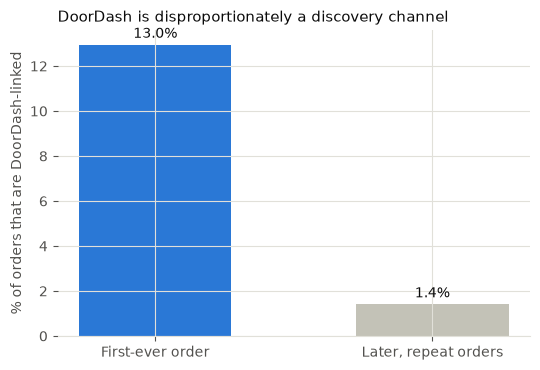

In [17]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
bars = ax.bar(["First-ever order", "Later, repeat orders"], [dd_share[True], dd_share[False]], color=[BLUE, GRAY_BASELINE], width=0.55)
for bar, value in zip(bars, [dd_share[True], dd_share[False]]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.3, f"{value:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("% of orders that are DoorDash-linked")
ax.set_title("DoorDash is disproportionately a discovery channel", loc="left", fontsize=11)
plt.tight_layout()
plt.show()


**Strong signal: DoorDash-linked numbers show up roughly 9x more often on a first order than on a repeat order.** That's a real, sizable gap — DoorDash is disproportionately a discovery channel, not a loyalty-order channel, for Tang's customers. One more check: has DoorDash's *share* of new-customer acquisition specifically been shrinking, growing, or holding steady — separate from the overall order-volume decline notebooks 04/05 already found.


In [18]:
first_orders_all = customers_sorted[customers_sorted["is_first"]].copy()
first_orders_all["month"] = first_orders_all["checkinTime"].dt.to_period("M")
first_orders_valid2 = first_orders_all[first_orders_all["month"].isin(FULL_MONTHS)]
first_orders_valid2 = first_orders_valid2[first_orders_valid2["month"] != sorted(first_orders_valid2["month"].unique())[0]]
first_orders_valid2["year"] = first_orders_valid2["month"].apply(lambda m: m.year)

yearly_dd_new = first_orders_valid2.groupby("year").agg(n_new=("customerID", "size"), n_dd=("is_doordash", "sum"))
yearly_dd_new["pct_via_dd"] = (100 * yearly_dd_new["n_dd"] / yearly_dd_new["n_new"]).round(1)
months_per_year2 = first_orders_valid2.groupby("year")["month"].nunique()
yearly_dd_new["dd_new_per_month"] = (yearly_dd_new["n_dd"] / months_per_year2).round(1)
print(yearly_dd_new)


      n_new  n_dd  pct_via_dd  dd_new_per_month
year                                           
2024   3524   395        11.2              35.9
2025   2400   338        14.1              28.2
2026    764   166        21.7              33.2


**DoorDash's *share* of new-customer discovery has nearly doubled — 11.2% (2024) → 14.1% (2025) → 21.7% (2026 so far)** — even as the raw monthly count of DoorDash-linked new customers has stayed roughly flat (~29-36/month, no clear decline). Put together with the 9x first-vs-repeat ratio above: **DoorDash isn't a shrinking acquisition channel — it's a stable one that's becoming a larger share of a shrinking pie**, as other discovery channels fade faster. That reframes this from "recover what's being lost" (notebooks 04/05) to "double down on what's already working relatively well."

**The action:** DoorDash's own paid promoted-placement / new-customer-discount ad product, run specifically to increase how often Tang surfaces in DoorDash search results for people who haven't ordered before.


In [19]:
current_dd_new_per_month = yearly_dd_new.loc[2026, "dd_new_per_month"]
ACQUISITION_LIFT = 0.25  # ILLUSTRATIVE -- Tang has no DoorDash ad-spend history to calibrate against

incremental_dd_new = current_dd_new_per_month * ACQUISITION_LIFT
THREAD5_MONTHLY = incremental_dd_new * avg_ticket_new

print(f"Current DoorDash-linked new customers/month: {current_dd_new_per_month:.0f}")
print(f"Incremental new customers from promoted placement (+{ACQUISITION_LIFT:.0%}): {incremental_dd_new:.1f}")
print(f"ESTIMATE (first-order revenue only): ~${THREAD5_MONTHLY:,.0f}/month")
print("(Doesn't include downstream repeat value -- per Thread 2, ~46% of these eventually become repeat customers too.)")


Current DoorDash-linked new customers/month: 33
Incremental new customers from promoted placement (+25%): 8.3
ESTIMATE (first-order revenue only): ~$308/month
(Doesn't include downstream repeat value -- per Thread 2, ~46% of these eventually become repeat customers too.)


### ✅ Thread 5 verdict: SURVIVES

**Action:** run DoorDash's promoted-placement / first-order-discount ad product, aimed at new-customer discovery specifically — justified now as a *growth* play (doubling down on a channel with a growing acquisition share), not just a recovery patch.
**Timeline:** ongoing; DoorDash ad placement typically shows results within a few weeks of activation.
**Confidence:** Medium (High on the 9x first-vs-repeat ratio and the growing acquisition-share trend, both directly measured; Medium on the +25% response to paid placement specifically, since Tang has no ad-spend history there).
**$ impact:** ~$308/month in first-order revenue alone — the smallest single number here, but understated on purpose: it excludes both the ad-spend cost (unknown, bid-based) *and* the downstream repeat-visit value these new customers go on to generate, so this should be read as a conservative floor, not the full picture.


In [20]:
combined_monthly = THREAD1_MONTHLY + THREAD2_MONTHLY + THREAD3_MONTHLY + THREAD4_MONTHLY + THREAD5_MONTHLY
print(f"Thread 1 (lapsed win-back, ongoing):     ${THREAD1_MONTHLY:,.0f}/mo")
print(f"Thread 2 (2nd-visit conversion):         ${THREAD2_MONTHLY:,.0f}/mo")
print(f"Thread 3 (Sunday promo):                 ${THREAD3_MONTHLY:,.0f}/mo")
print(f"Thread 4 (top-10% referral):              ${THREAD4_MONTHLY:,.0f}/mo")
print(f"Thread 5 (DoorDash discovery):            ${THREAD5_MONTHLY:,.0f}/mo")
print(f"{'-'*45}")
print(f"COMBINED ONGOING MONTHLY:                ${combined_monthly:,.0f}/mo")
print(f"Plus Thread 1's one-time initial sweep:  ${THREAD1_ONE_TIME:,.0f}")


Thread 1 (lapsed win-back, ongoing):     $2,553/mo
Thread 2 (2nd-visit conversion):         $563/mo
Thread 3 (Sunday promo):                 $851/mo
Thread 4 (top-10% referral):              $1,853/mo
Thread 5 (DoorDash discovery):            $308/mo
---------------------------------------------
COMBINED ONGOING MONTHLY:                $6,127/mo
Plus Thread 1's one-time initial sweep:  $7,659


## Summary — ranked recommendations

All five requested threads survived testing — none were dropped this time, though every dollar figure leans conservative and every assumption is labeled rather than hidden. Ranked by a combination of confidence and dollar impact:

| # | Action | Timeline | Confidence | $ Impact |
|---|---|---|---|---|
| 1 | **"Bring a friend" 20% off**, targeted only at the top 10% of customers by visit frequency (780 people) | Ongoing, launch immediately | Medium (Low-Medium on the referral-rate assumption specifically) | ~$1,853/mo |
| 2 | **Text lapsed customers a 10%-off code** — 978 people quiet 90-180 days, 5,161 quiet 180+ days | Initial sweep now, then ~quarterly | Medium | ~$7,659 one-time, ~$2,553/mo ongoing |
| 3 | **"Sunday Family Meal," 15% off orders over $40** — Sunday is the lowest-volume day and has the highest average ticket | Weekly, launch immediately | Medium | ~$851/mo |
| 4 | **DoorDash promoted placement**, aimed at new-customer discovery specifically | Ongoing | Medium | ~$308/mo (understated — excludes ad cost and repeat-visit value) |
| 5 | **15% off the next order**, texted 1-2 weeks after a customer's first-ever visit | Ongoing, automatic trigger | Medium | ~$563/mo (smallest single number, but compounding — each conversion is a new repeat customer, not a one-off) |

**Combined, if every estimate lands as modeled: ~$6,127/month ongoing, plus a ~$7,659 one-time lapsed-customer sweep.** Every number here assumes the stated response/lift rates hold — none of them are measured from a prior Tang campaign, since Tang hasn't run these before. Treat this as a realistic starting scale, not a guarantee, and as reasons to test small before rolling out big (e.g. try the referral card with a subset of the top-10% list first, see what response actually looks like, then adjust the assumption before betting the full estimate on it).
